In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("C:/Users/muham/Desktop/Tahniyat_code/Task_5/bank-full.csv", sep=";")

print("Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nBasic Statistics:\n", df.describe())

Shape: (45211, 17)

First 5 Rows:
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  

Data Types:
 age          int64
job            str
marital        str
educat

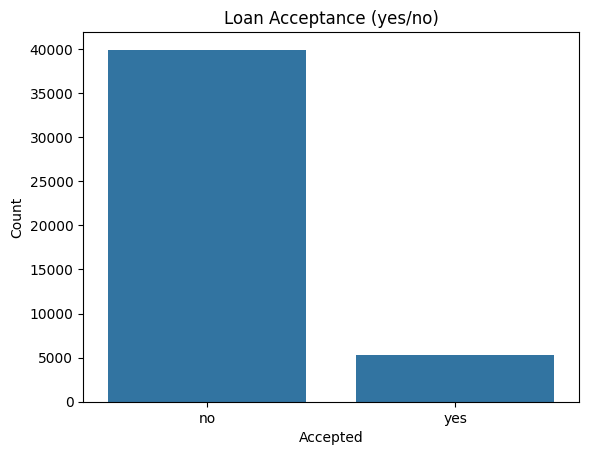


Acceptance Rate:
 y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64


In [3]:
plt.figure()
sns.countplot(x=df["y"])
plt.title("Loan Acceptance (yes/no)")
plt.xlabel("Accepted")
plt.ylabel("Count")
plt.show()
acceptance_rate = df["y"].value_counts(normalize=True) * 100
print("\nAcceptance Rate:\n", acceptance_rate)


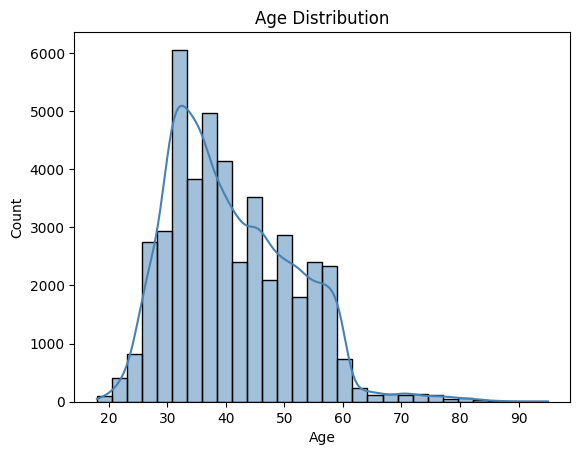

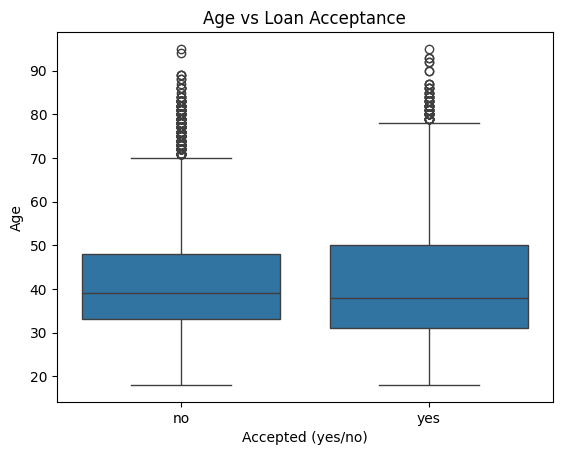

In [4]:
plt.figure()
sns.histplot(df["age"], bins=30, kde=True, color="steelblue")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

plt.figure()
sns.boxplot(x=df["y"], y=df["age"])
plt.title("Age vs Loan Acceptance")
plt.xlabel("Accepted (yes/no)")
plt.ylabel("Age")
plt.show()

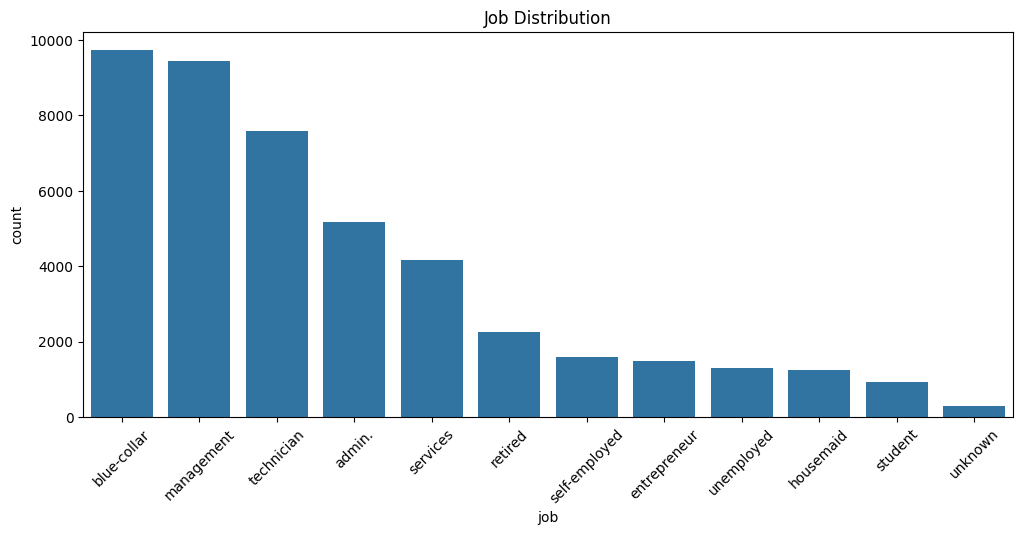

C:\Users\muham\AppData\Local\Temp\ipykernel_6148\959526528.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=job_acceptance.index, y=job_acceptance.values, palette="viridis")


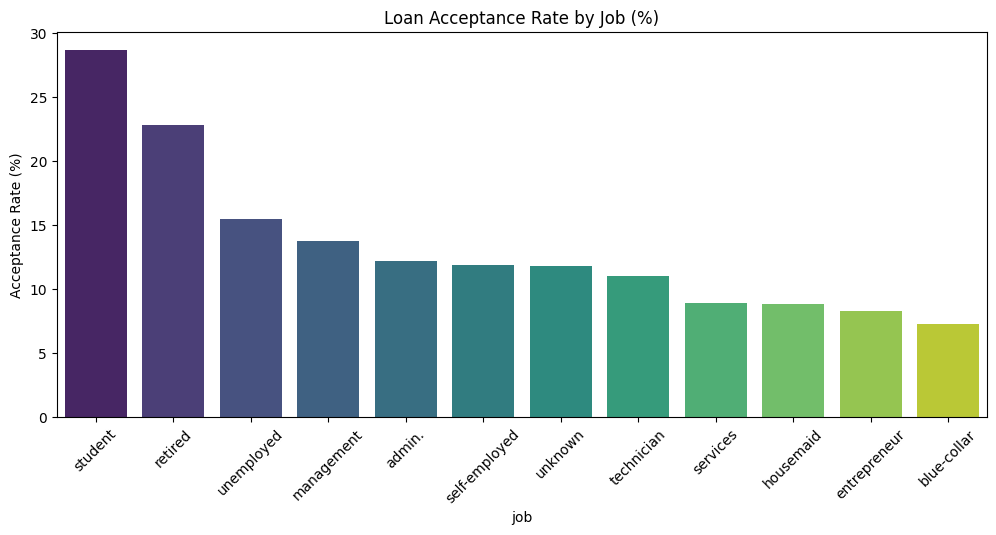


Acceptance Rate by Job:
 job
student          28.678038
retired          22.791519
unemployed       15.502686
management       13.755551
admin.           12.202669
self-employed    11.842939
unknown          11.805556
technician       11.056996
services          8.883004
housemaid         8.790323
entrepreneur      8.271688
blue-collar       7.274969
Name: y, dtype: float64


In [5]:
plt.figure(figsize=(12, 5))
sns.countplot(x=df["job"], order=df["job"].value_counts().index)
plt.title("Job Distribution")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12, 5))
job_acceptance = df.groupby("job")["y"].apply(
    lambda x: (x == "yes").sum() / len(x) * 100
).sort_values(ascending=False)
sns.barplot(x=job_acceptance.index, y=job_acceptance.values, palette="viridis")
plt.title("Loan Acceptance Rate by Job (%)")
plt.xticks(rotation=45)
plt.ylabel("Acceptance Rate (%)")
plt.show()

print("\nAcceptance Rate by Job:\n", job_acceptance)

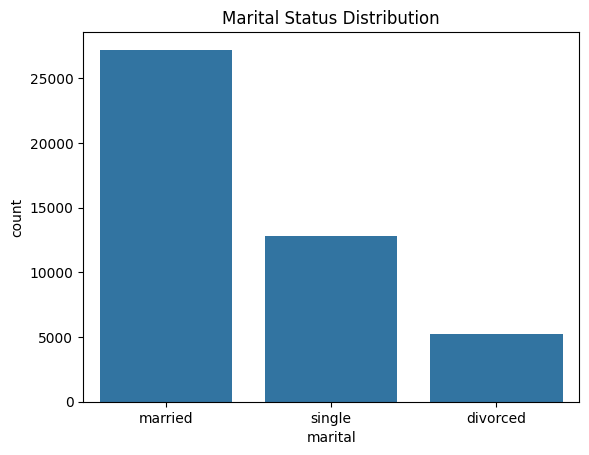

C:\Users\muham\AppData\Local\Temp\ipykernel_6148\1346664884.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=marital_acceptance.index, y=marital_acceptance.values, palette="coolwarm")


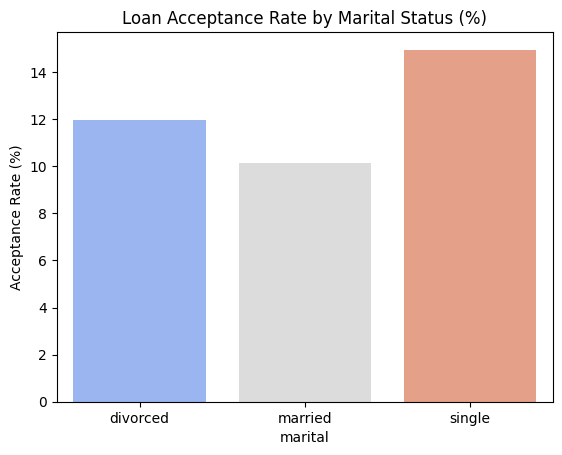

In [6]:
plt.figure()
sns.countplot(x=df["marital"])
plt.title("Marital Status Distribution")
plt.show()

plt.figure()
marital_acceptance = df.groupby("marital")["y"].apply(
    lambda x: (x == "yes").sum() / len(x) * 100
)
sns.barplot(x=marital_acceptance.index, y=marital_acceptance.values, palette="coolwarm")
plt.title("Loan Acceptance Rate by Marital Status (%)")
plt.ylabel("Acceptance Rate (%)")
plt.show()

C:\Users\muham\AppData\Local\Temp\ipykernel_6148\3799349077.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=edu_acceptance.index, y=edu_acceptance.values, palette="magma")


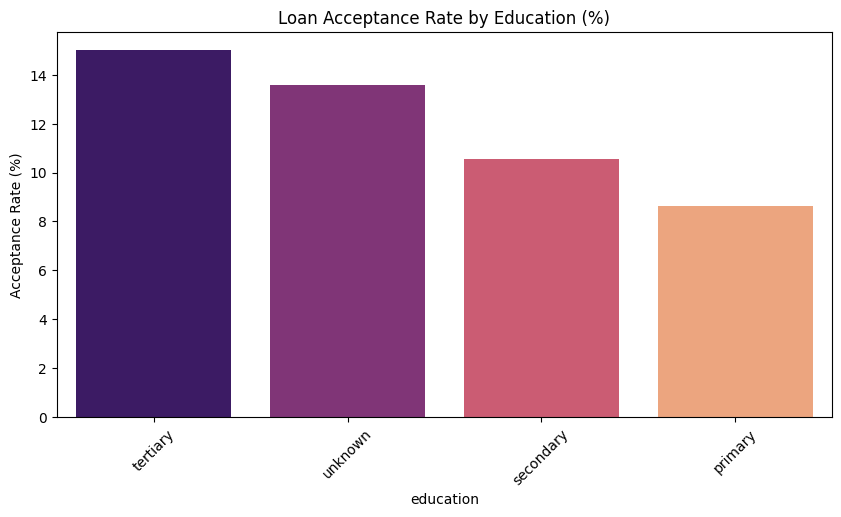

In [7]:
plt.figure(figsize=(10, 5))
edu_acceptance = df.groupby("education")["y"].apply(
    lambda x: (x == "yes").sum() / len(x) * 100
).sort_values(ascending=False)
sns.barplot(x=edu_acceptance.index, y=edu_acceptance.values, palette="magma")
plt.title("Loan Acceptance Rate by Education (%)")
plt.xticks(rotation=45)
plt.ylabel("Acceptance Rate (%)")
plt.show()

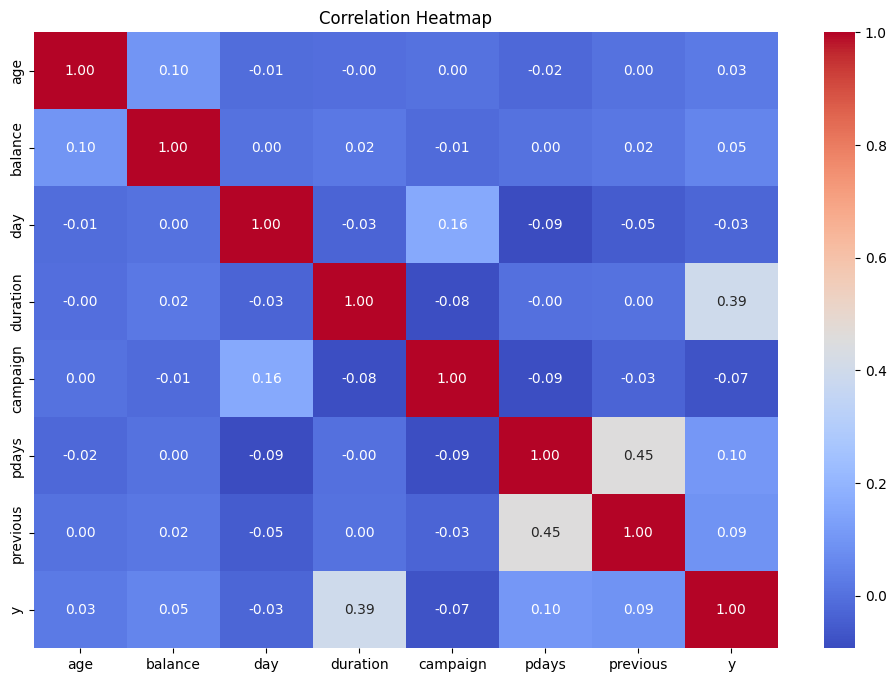

In [8]:
plt.figure(figsize=(12, 8))
df_encoded = df.copy()
df_encoded["y"] = df_encoded["y"].map({"yes": 1, "no": 0})
numeric_df = df_encoded.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [9]:
df_encoded.to_csv("bank_EDA_processed.csv", index=False)
print("\nProcessed file saved: bank_EDA_processed.csv")


Processed file saved: bank_EDA_processed.csv
